In [1]:
# Import required libraries
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Merlion imports
from merlion.models.forecast.moirai import Moirai, MoiraiConfig
from merlion.utils import TimeSeries

print("✓ All imports successful")

✓ All imports successful


## 1. Load Sample Data

We'll use the same dataset as before for consistency.

Total length: 1824
Time frequency: 0 days 01:00:00
Date range: 2024-06-10 00:00:00 to 2024-08-24 23:00:00


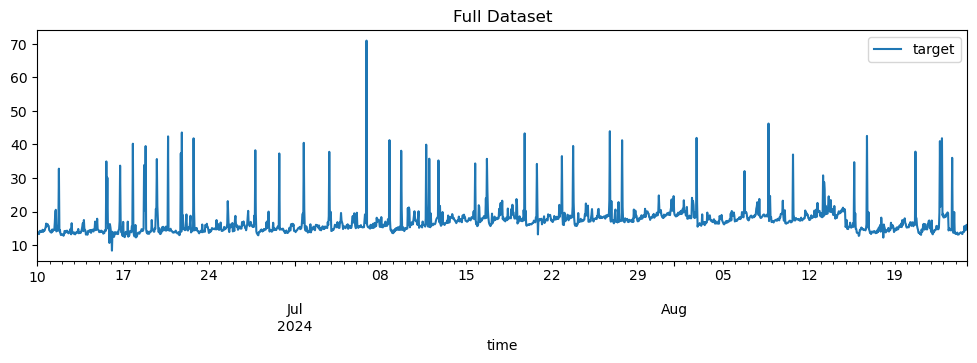

In [2]:
# Load dataframe
url = (
    "https://gist.githubusercontent.com/rsnirwan/a8b424085c9f44ef2598da74ce43e7a3"
    "/raw/b6fdef21fe1f654787fa0493846c546b7f9c4df2/ts_long.csv"
)
url = "/home/sriteja/Research/cpu_data/main_data_1H/1.csv" # time, value
df = pd.read_csv(url, index_col=0, parse_dates=True)
# df = df[df["item_id"] == "A"].drop(columns=["item_id"])
df = df.rename(columns={'value': 'target'})

print(f"Total length: {df.shape[0]}")
print(f"Time frequency: {df.index.diff()[1]}")
print(f"Date range: {df.index[0]} to {df.index[-1]}")

# Plot the full dataset
df.plot(figsize=(12, 3))
plt.title("Full Dataset")
plt.show()


## 2. Setup Moirai Model

First, we need to train a model on some initial data.

In [3]:
# Use first 168 hours (1 week) as training data
TRAIN_LENGTH = 168
train_df = df.iloc[:TRAIN_LENGTH]
train_ts = TimeSeries.from_pd(train_df)

# Configure Merlion Moirai2 model
print("Configuring Merlion Moirai2 model...")
config = MoiraiConfig(
    max_forecast_steps=48,
    model_variant="moirai2",
    model_size="small",
    context_length=168,
    target_seq_index=0,
    device="auto",
)

# Initialize and train
print("Loading and training Merlion Moirai2 model...")
model = Moirai(config)
model.train(train_ts)

print("✓ Model trained successfully")

Configuring Merlion Moirai2 model...
Loading and training Merlion Moirai2 model...
✓ Model trained successfully
✓ Model trained successfully


## 3. Traditional Forecast vs Rolling Forecast

Let's compare a traditional single forecast with the new rolling forecast feature.

In [4]:
# Prepare the full time series for rolling forecast
full_ts = TimeSeries.from_pd(df)

# Rolling forecast parameters
CONTEXT_LENGTH = 168  # 1 week
PREDICTION_LENGTH = 24  # 1 day
PREDICTION_STRIDE = 24  # Move 1 day forward each time (non-overlapping)

print(f"Performing rolling forecast...")
print(f"Context length: {CONTEXT_LENGTH} hours")
print(f"Prediction length: {PREDICTION_LENGTH} hours")
print(f"Prediction stride: {PREDICTION_STRIDE} hours")

# Perform rolling forecast
rolling_forecast, rolling_err = model.rolling_forecast(
    time_series=full_ts,
    context_length=CONTEXT_LENGTH,
    prediction_length=PREDICTION_LENGTH,
    prediction_stride=PREDICTION_STRIDE,
)

print(f"\n✓ Rolling forecast complete")
print(f"Generated {len(rolling_forecast)} predictions")
print(f"Prediction range: {rolling_forecast.time_stamps[0]} to {rolling_forecast.time_stamps[-1]}")

Performing rolling forecast...
Context length: 168 hours
Prediction length: 24 hours
Prediction stride: 24 hours

✓ Rolling forecast complete
Generated 1656 predictions
Prediction range: 1718582400.0 to 1724540400.0

✓ Rolling forecast complete
Generated 1656 predictions
Prediction range: 1718582400.0 to 1724540400.0


## 4. Visualize Rolling Forecast

Let's plot the original data and the rolling forecast predictions.

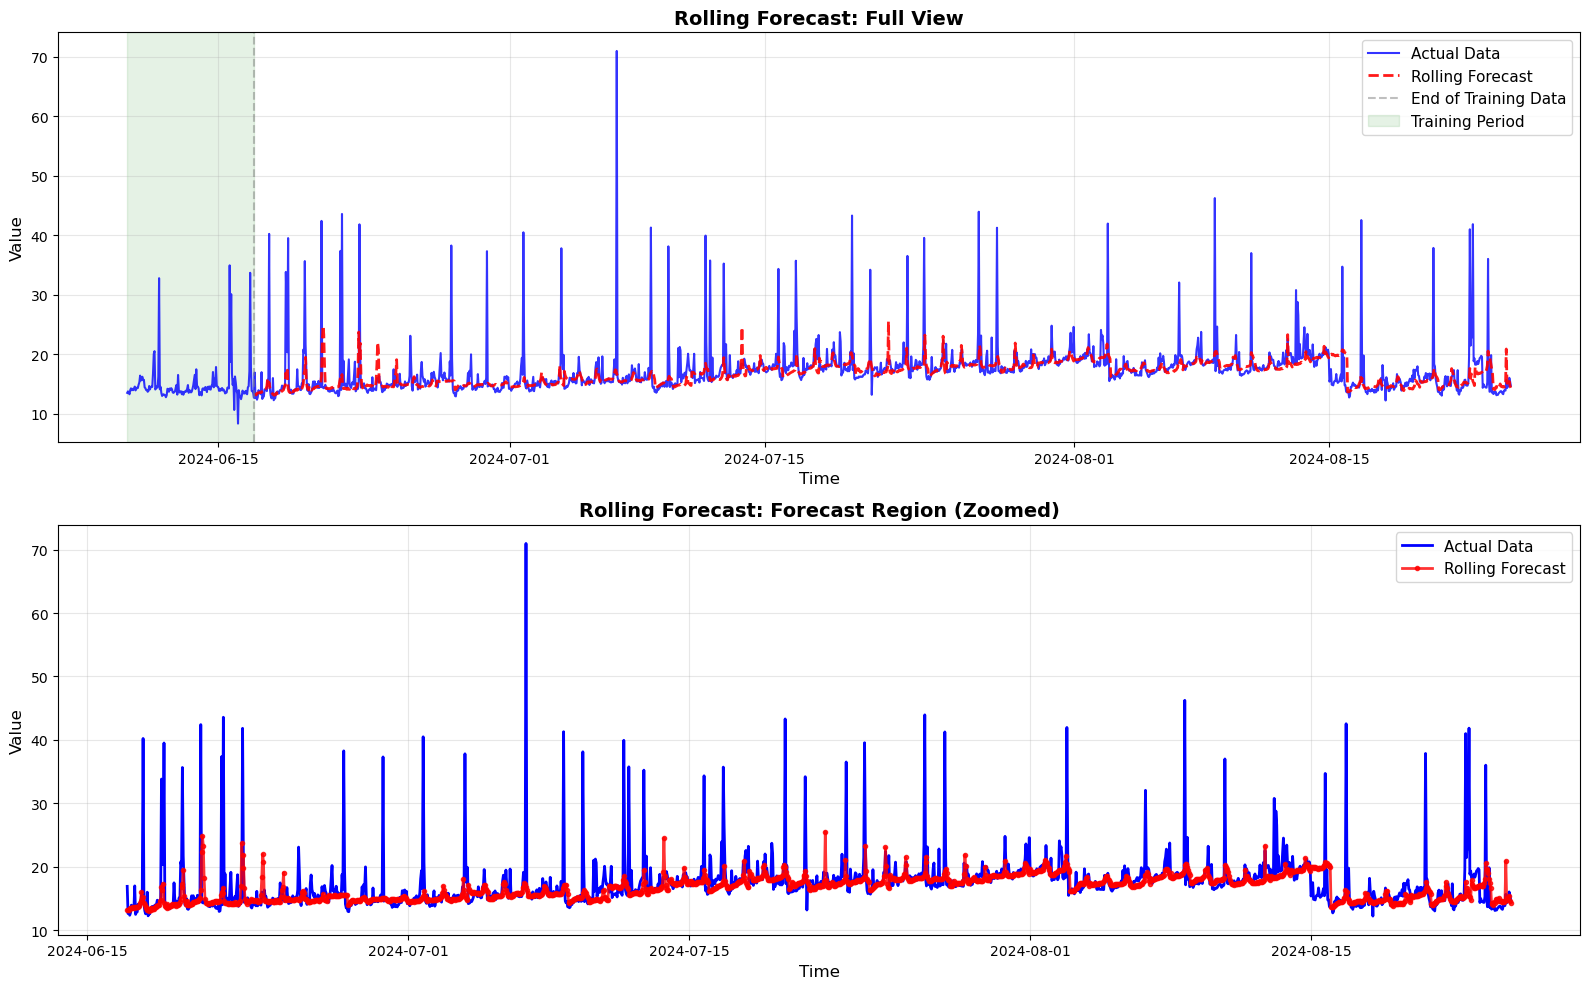

In [5]:
# Create visualization
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Plot 1: Full view
ax1 = axes[0]
ax1.plot(df.index, df['target'], label='Actual Data', color='blue', linewidth=1.5, alpha=0.8)

# Plot rolling forecast
rolling_forecast_df = rolling_forecast.to_pd()
ax1.plot(rolling_forecast_df.index, rolling_forecast_df.values, 
         label='Rolling Forecast', color='red', linewidth=2, alpha=0.9, linestyle='--')

# Mark the training period
ax1.axvline(x=df.index[TRAIN_LENGTH-1], color='gray', linestyle='--', 
            alpha=0.5, label='End of Training Data')
ax1.axvspan(df.index[0], df.index[TRAIN_LENGTH-1], alpha=0.1, color='green', 
            label='Training Period')

ax1.set_xlabel('Time', fontsize=12)
ax1.set_ylabel('Value', fontsize=12)
ax1.set_title('Rolling Forecast: Full View', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Plot 2: Zoomed into forecast region
ax2 = axes[1]
forecast_start_idx = TRAIN_LENGTH
df_forecast_region = df.iloc[forecast_start_idx:]

ax2.plot(df_forecast_region.index, df_forecast_region['target'], 
         label='Actual Data', color='blue', linewidth=2)
ax2.plot(rolling_forecast_df.index, rolling_forecast_df.values, 
         label='Rolling Forecast', color='red', linewidth=2, 
         marker='o', markersize=3, alpha=0.8)

ax2.set_xlabel('Time', fontsize=12)
ax2.set_ylabel('Value', fontsize=12)
ax2.set_title('Rolling Forecast: Forecast Region (Zoomed)', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Calculate Forecast Accuracy

Let's evaluate the rolling forecast performance.

In [6]:
# Get actual values for the forecast period
forecast_df = rolling_forecast.to_pd()
actual_values = df.loc[forecast_df.index, 'target'].values
predicted_values = forecast_df.values.flatten()

# Calculate metrics
mae = np.mean(np.abs(actual_values - predicted_values))
rmse = np.sqrt(np.mean((actual_values - predicted_values) ** 2))
mape = np.mean(np.abs((actual_values - predicted_values) / actual_values)) * 100

print("=" * 80)
print("ROLLING FORECAST PERFORMANCE")
print("=" * 80)
print(f"Number of predictions: {len(predicted_values)}")
print(f"Prediction period: {forecast_df.index[0]} to {forecast_df.index[-1]}")
print(f"\nMetrics:")
print(f"  MAE:  {mae:.4f}")
print(f"  RMSE: {rmse:.4f}")
print(f"  MAPE: {mape:.2f}%")
print("=" * 80)

ROLLING FORECAST PERFORMANCE
Number of predictions: 1656
Prediction period: 2024-06-17 00:00:00 to 2024-08-24 23:00:00

Metrics:
  MAE:  1.5023
  RMSE: 3.7981
  MAPE: 7.06%


## 6. Experiment with Different Window Configurations

Let's try overlapping windows by using a smaller prediction stride.

In [7]:
# Try overlapping windows (stride < prediction_length)
OVERLAPPING_STRIDE = 12  # Move 12 hours forward (50% overlap)

print(f"Performing rolling forecast with overlapping windows...")
print(f"Context length: {CONTEXT_LENGTH} hours")
print(f"Prediction length: {PREDICTION_LENGTH} hours")
print(f"Prediction stride: {OVERLAPPING_STRIDE} hours (50% overlap)")

# Perform rolling forecast with overlapping windows
overlapping_forecast, overlapping_err = model.rolling_forecast(
    time_series=full_ts,
    context_length=CONTEXT_LENGTH,
    prediction_length=PREDICTION_LENGTH,
    prediction_stride=OVERLAPPING_STRIDE,
)

print(f"\n✓ Overlapping rolling forecast complete")
print(f"Generated {len(overlapping_forecast)} predictions")
print(f"(Note: Duplicates are removed, keeping first prediction for each timestamp)")

Performing rolling forecast with overlapping windows...
Context length: 168 hours
Prediction length: 24 hours
Prediction stride: 12 hours (50% overlap)

✓ Overlapping rolling forecast complete
Generated 1656 predictions
(Note: Duplicates are removed, keeping first prediction for each timestamp)

✓ Overlapping rolling forecast complete
Generated 1656 predictions
(Note: Duplicates are removed, keeping first prediction for each timestamp)


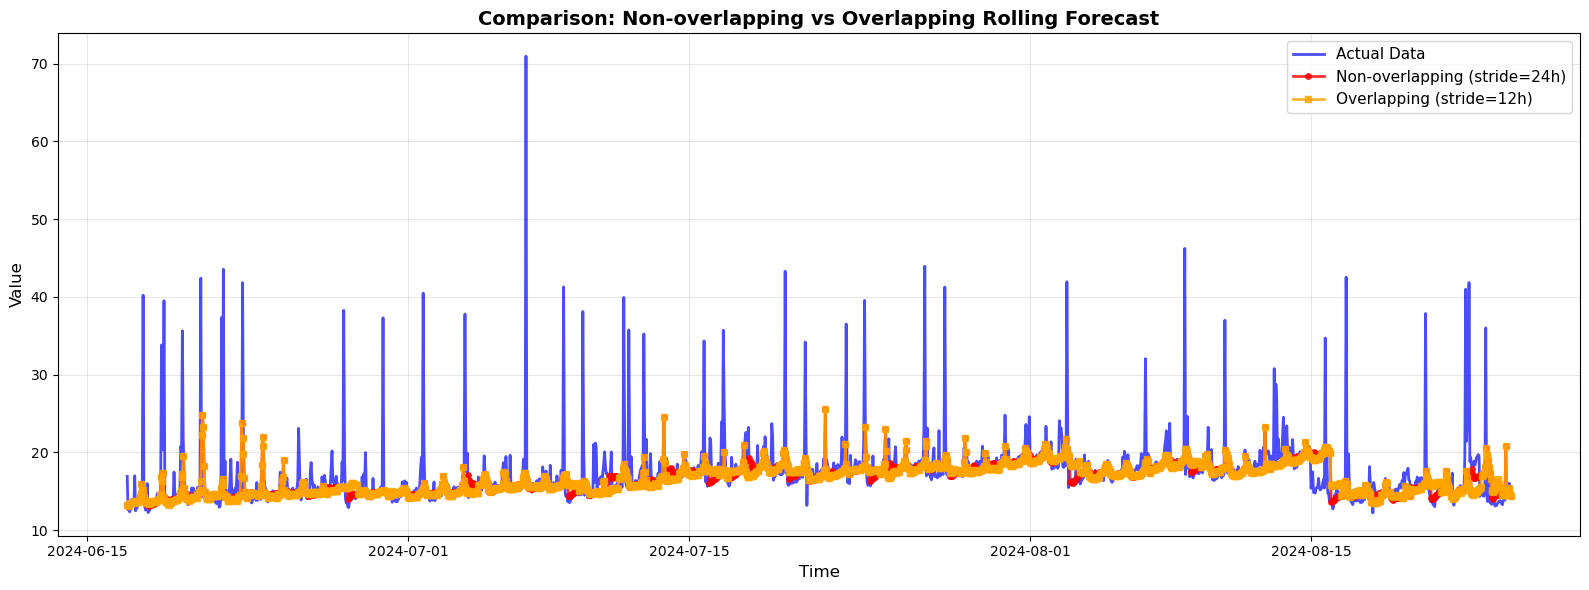

In [8]:
# Compare non-overlapping vs overlapping
fig, ax = plt.subplots(1, 1, figsize=(16, 6))

# Plot actual data
df_forecast_region = df.iloc[TRAIN_LENGTH:]
ax.plot(df_forecast_region.index, df_forecast_region['target'], 
        label='Actual Data', color='blue', linewidth=2, alpha=0.7)

# Plot non-overlapping forecast
rolling_forecast_df = rolling_forecast.to_pd()
ax.plot(rolling_forecast_df.index, rolling_forecast_df.values, 
        label=f'Non-overlapping (stride={PREDICTION_STRIDE}h)', 
        color='red', linewidth=2, marker='o', markersize=4, alpha=0.8)

# Plot overlapping forecast
overlapping_forecast_df = overlapping_forecast.to_pd()
ax.plot(overlapping_forecast_df.index, overlapping_forecast_df.values, 
        label=f'Overlapping (stride={OVERLAPPING_STRIDE}h)', 
        color='orange', linewidth=2, marker='s', markersize=4, alpha=0.8)

ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Value', fontsize=12)
ax.set_title('Comparison: Non-overlapping vs Overlapping Rolling Forecast', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Summary

The new `rolling_forecast` method provides a convenient way to:

1. **Perform sliding window predictions** - Automatically handles the windowing logic
2. **Control window overlap** - Use `prediction_stride` to create overlapping or non-overlapping windows
3. **Works with any forecaster** - Available for all models inheriting from `ForecasterBase`
4. **Handles duplicates** - Automatically removes duplicate predictions (keeps first occurrence)
5. **Supports exogenous data** - Can include external variables if supported by the model

### Key Parameters:
- `context_length`: Number of historical time steps used for each prediction
- `prediction_length`: Number of future time steps to predict in each window
- `prediction_stride`: How far to move the window (defaults to `prediction_length`)

### Example Use Cases:
- **Real-time forecasting** - Simulate how a model would perform in production
- **Model evaluation** - Test forecast accuracy across different time periods
- **Ensemble forecasting** - Combine overlapping predictions for smoother results

## 8. Testing Dashboard API - Rolling Forecast

Now let's test the rolling forecast using the Merlion dashboard API, which provides both rolling forecast modes:
- **rolling_update**: Updates context with actual values (traditional approach)
- **rolling_sliding**: Efficient sliding window (same as direct API above)

In [9]:
# Import dashboard API
from merlion.dashboard.models.forecast import ForecastModel
import logging

# Setup logger
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# Create dashboard model instance
dashboard_model = ForecastModel()

print("✓ Dashboard API imported successfully")

✓ Dashboard API imported successfully


In [10]:
# Prepare data in the format expected by dashboard API
# Split into train and test
train_dashboard_df = df.iloc[:TRAIN_LENGTH].copy()
test_dashboard_df = df.iloc[TRAIN_LENGTH:].copy()

print(f"Training data: {len(train_dashboard_df)} points")
print(f"Test data: {len(test_dashboard_df)} points")
print(f"Train range: {train_dashboard_df.index[0]} to {train_dashboard_df.index[-1]}")
print(f"Test range: {test_dashboard_df.index[0]} to {test_dashboard_df.index[-1]}")

Training data: 168 points
Test data: 1656 points
Train range: 2024-06-10 00:00:00 to 2024-06-16 23:00:00
Test range: 2024-06-17 00:00:00 to 2024-08-24 23:00:00


### 8.1 Test Rolling Forecast - Sliding Window Mode

This uses the new efficient sliding window approach (same as the direct API above).

### ⚠️ Important: Setting max_forecast_steps

**Critical for avoiding flat line predictions!**

The Moirai model has a `max_forecast_steps` parameter that limits how many steps it can generate in a single forecast call. If you request more steps than this limit, the model will raise an error instead of padding with the last value (which would create a flat line).

**Best Practices:**
- For **rolling forecast**, set `max_forecast_steps` = `prediction_length` (the window size)
- For **single forecast**, set `max_forecast_steps` ≥ total forecast horizon
- Default is 100 steps if not specified

**Example issue:**
- If `max_forecast_steps=24` but you request 365 steps in single forecast mode → Error!
- Solution: Either set `max_forecast_steps=365` OR use rolling forecast with `prediction_length=24`

In [11]:
# Progress callback (dashboard uses this for UI updates)
def progress_callback(progress_tuple):
    current, total = progress_tuple
    # Silently update progress (don't print in notebook)
    pass

# Train with dashboard API using rolling_sliding mode
print("Training with Dashboard API - Rolling Sliding Mode")
print("=" * 60)

dashboard_model_sliding, train_metrics, test_metrics, figure = dashboard_model.train(
    algorithm="Moirai",  # Use "Moirai" not "Moirai2" - it's the registered name
    train_df=train_dashboard_df,
    test_df=test_dashboard_df,
    target_column='target',  # Required: column name for target variable
    feature_columns=[],      # Required: list of feature columns (empty for univariate)
    exog_columns=None,       # Optional: exogenous variables
    params={
        "model_variant": "moirai2",
        "model_size": "small",
        "context_length": CONTEXT_LENGTH,
        "max_forecast_steps": PREDICTION_LENGTH,  # IMPORTANT: Set this to prediction window size!
    },
    forecast_mode="rolling_sliding",  # Use sliding window mode
    rolling_window_size=PREDICTION_LENGTH,
    context_length=CONTEXT_LENGTH,
    prediction_stride=PREDICTION_STRIDE,
    set_progress=progress_callback,
)

print("\n✓ Dashboard API training complete (rolling_sliding mode)")
print(f"\nTest Metrics:")
for metric, value in test_metrics.items():
    print(f"  {metric}: {value:.4f}")

Training with Dashboard API - Rolling Sliding Mode


INFO:merlion.dashboard.models.forecast:Training the forecasting model: Moirai...
INFO:merlion.models.forecast.moirai:Loading pretrained MOIRAI model: Salesforce/moirai-2.0-R-small
INFO:merlion.models.forecast.moirai:Loading pretrained MOIRAI model: Salesforce/moirai-2.0-R-small
INFO:merlion.models.forecast.moirai:Using device: cpu
INFO:merlion.models.forecast.moirai:Successfully loaded MOIRAI moirai2 (small) model
INFO:merlion.models.forecast.moirai:MOIRAI is a pretrained model - no additional training performed
INFO:merlion.models.forecast.moirai:Using device: cpu
INFO:merlion.models.forecast.moirai:Successfully loaded MOIRAI moirai2 (small) model
INFO:merlion.models.forecast.moirai:MOIRAI is a pretrained model - no additional training performed
INFO:merlion.dashboard.models.forecast:Computing training performance metrics...
INFO:merlion.dashboard.models.forecast:Computing training performance metrics...
INFO:merlion.dashboard.models.forecast:Using rolling forecast (sliding window) mo

ValueError: Model can only generate 24 steps (max_forecast_steps=24), but 1656 were requested. Please either:
  1. Set max_forecast_steps=1656 or higher in MoiraiConfig, OR
  2. Use rolling_forecast() method for longer forecast horizons.
Example: model.rolling_forecast(time_series=ts, context_length=168, prediction_length=24, prediction_stride=24)

### ⚠️ Important: Reload the Module

If you get a `TypeError: Invalid comparison between dtype=datetime64[ns] and float` error, you need to restart the kernel to reload the updated dashboard code.

**To fix:**
1. Go to **Kernel** → **Restart Kernel** (or press the restart button)
2. Re-run all cells from the beginning

Alternatively, you can reload the module by running the next cell:

In [ ]:
# Reload the dashboard module to pick up the latest fixes
import importlib
import sys

# Remove cached modules
if 'merlion.dashboard.models.forecast' in sys.modules:
    del sys.modules['merlion.dashboard.models.forecast']
if 'merlion.dashboard.models' in sys.modules:
    del sys.modules['merlion.dashboard.models']

# Re-import
from merlion.dashboard.models.forecast import ForecastModel

# Create fresh dashboard model instance
dashboard_model = ForecastModel()

print("✓ Dashboard module reloaded successfully")

### 8.2 Test Rolling Forecast - Context Update Mode

This uses the traditional approach where context is updated with actual values after each prediction window.

In [ ]:
# Create a new dashboard model instance for context update mode
dashboard_model_update = ForecastModel()

# Train with dashboard API using rolling_update mode
print("Training with Dashboard API - Rolling Update Mode")
print("=" * 60)

dashboard_model_update_trained, train_metrics_update, test_metrics_update, figure_update = dashboard_model_update.train(
    algorithm="Moirai",  # Use "Moirai" not "Moirai2" - it's the registered name
    train_df=train_dashboard_df,
    test_df=test_dashboard_df,
    target_column='target',  # Required: column name for target variable
    feature_columns=[],      # Required: list of feature columns (empty for univariate)
    exog_columns=None,       # Optional: exogenous variables
    params={
        "model_variant": "moirai2",
        "model_size": "small",
        "context_length": CONTEXT_LENGTH,
        "max_forecast_steps": PREDICTION_LENGTH,  # IMPORTANT: Set this to prediction window size!
    },
    forecast_mode="rolling_update",  # Use context update mode
    rolling_window_size=PREDICTION_LENGTH,
    context_length=CONTEXT_LENGTH,
    prediction_stride=PREDICTION_STRIDE,
    set_progress=progress_callback,
)

print("\n✓ Dashboard API training complete (rolling_update mode)")
print(f"\nTest Metrics:")
for metric, value in test_metrics_update.items():
    print(f"  {metric}: {value:.4f}")

Training with Dashboard API - Rolling Update Mode


INFO:merlion.dashboard.models.forecast:Training the forecasting model: Moirai...
INFO:merlion.models.forecast.moirai:Loading pretrained MOIRAI model: Salesforce/moirai-2.0-R-small
INFO:merlion.models.forecast.moirai:Loading pretrained MOIRAI model: Salesforce/moirai-2.0-R-small
INFO:merlion.models.forecast.moirai:Using device: cpu
INFO:merlion.models.forecast.moirai:Successfully loaded MOIRAI moirai2 (small) model
INFO:merlion.models.forecast.moirai:MOIRAI is a pretrained model - no additional training performed
INFO:merlion.dashboard.models.forecast:Computing training performance metrics...
INFO:merlion.models.forecast.moirai:Using device: cpu
INFO:merlion.models.forecast.moirai:Successfully loaded MOIRAI moirai2 (small) model
INFO:merlion.models.forecast.moirai:MOIRAI is a pretrained model - no additional training performed
INFO:merlion.dashboard.models.forecast:Computing training performance metrics...
INFO:merlion.dashboard.models.forecast:Using rolling forecast (context update) mo


✓ Dashboard API training complete (rolling_update mode)

Test Metrics:
  MAE: 1.5023
  MARRE: 2.5577
  RMSE: 3.7981
  sMAPE: 7.5519
  RMSPE: 12.3769


### 8.3 Compare All Three Approaches

Let's visualize and compare:
1. Direct API - Sliding Window (from Section 3)
2. Dashboard API - Sliding Window 
3. Dashboard API - Context Update

In [ ]:
# The rolling forecast predictions were already generated during training!
# The train() method returns them, but we need to extract them properly.

# For dashboard API, the rolling forecasts were computed during the train() call
# We need to re-run the rolling forecasts to get the actual predictions

# Dashboard sliding mode - use rolling_forecast directly
dashboard_sliding_pred, _ = dashboard_model_sliding.rolling_forecast(
    time_series=train_ts + test_ts,
    context_length=CONTEXT_LENGTH,
    prediction_length=PREDICTION_LENGTH,
    prediction_stride=PREDICTION_STRIDE,
    return_iqr=False,
)

# Extract only test portion
dashboard_sliding_pred = dashboard_sliding_pred.window(
    test_ts.time_stamps[0], test_ts.time_stamps[-1], include_tf=True
)

# For context update mode, we need to manually run the rolling forecast
# Since it updates context with actual values, let's use the helper method
from merlion.utils.time_series import TimeSeries as TS

# Re-create test_ts from dashboard dataframe
test_ts = TimeSeries.from_pd(test_dashboard_df)

# For rolling update, we simulate the incremental prediction
all_preds_update = []
current_context_update = train_ts
window_size = PREDICTION_LENGTH

for i in range(0, len(test_ts), window_size):
    end_idx = min(i + window_size, len(test_ts))
    window_timestamps = test_ts.time_stamps[i:end_idx]
    
    # Predict this window
    pred, _ = dashboard_model_update_trained.forecast(
        time_stamps=window_timestamps,
        time_series_prev=current_context_update
    )
    all_preds_update.append(pred)
    
    # Update context with actual values
    actual_window = test_ts.window(window_timestamps[0], window_timestamps[-1], include_tf=True)
    current_context_update = current_context_update + actual_window

# Concatenate all update predictions
dashboard_update_pred = all_preds_update[0]
for pred in all_preds_update[1:]:
    dashboard_update_pred = dashboard_update_pred + pred

print("✓ Generated rolling forecast predictions from both dashboard models")
print(f"Dashboard sliding predictions: {len(dashboard_sliding_pred)}")
print(f"Dashboard update predictions: {len(dashboard_update_pred)}")
print(f"Direct API predictions: {len(rolling_forecast)}")

✓ Generated rolling forecast predictions from both dashboard models
Dashboard sliding predictions: 1656
Dashboard update predictions: 1656
Direct API predictions: 1656


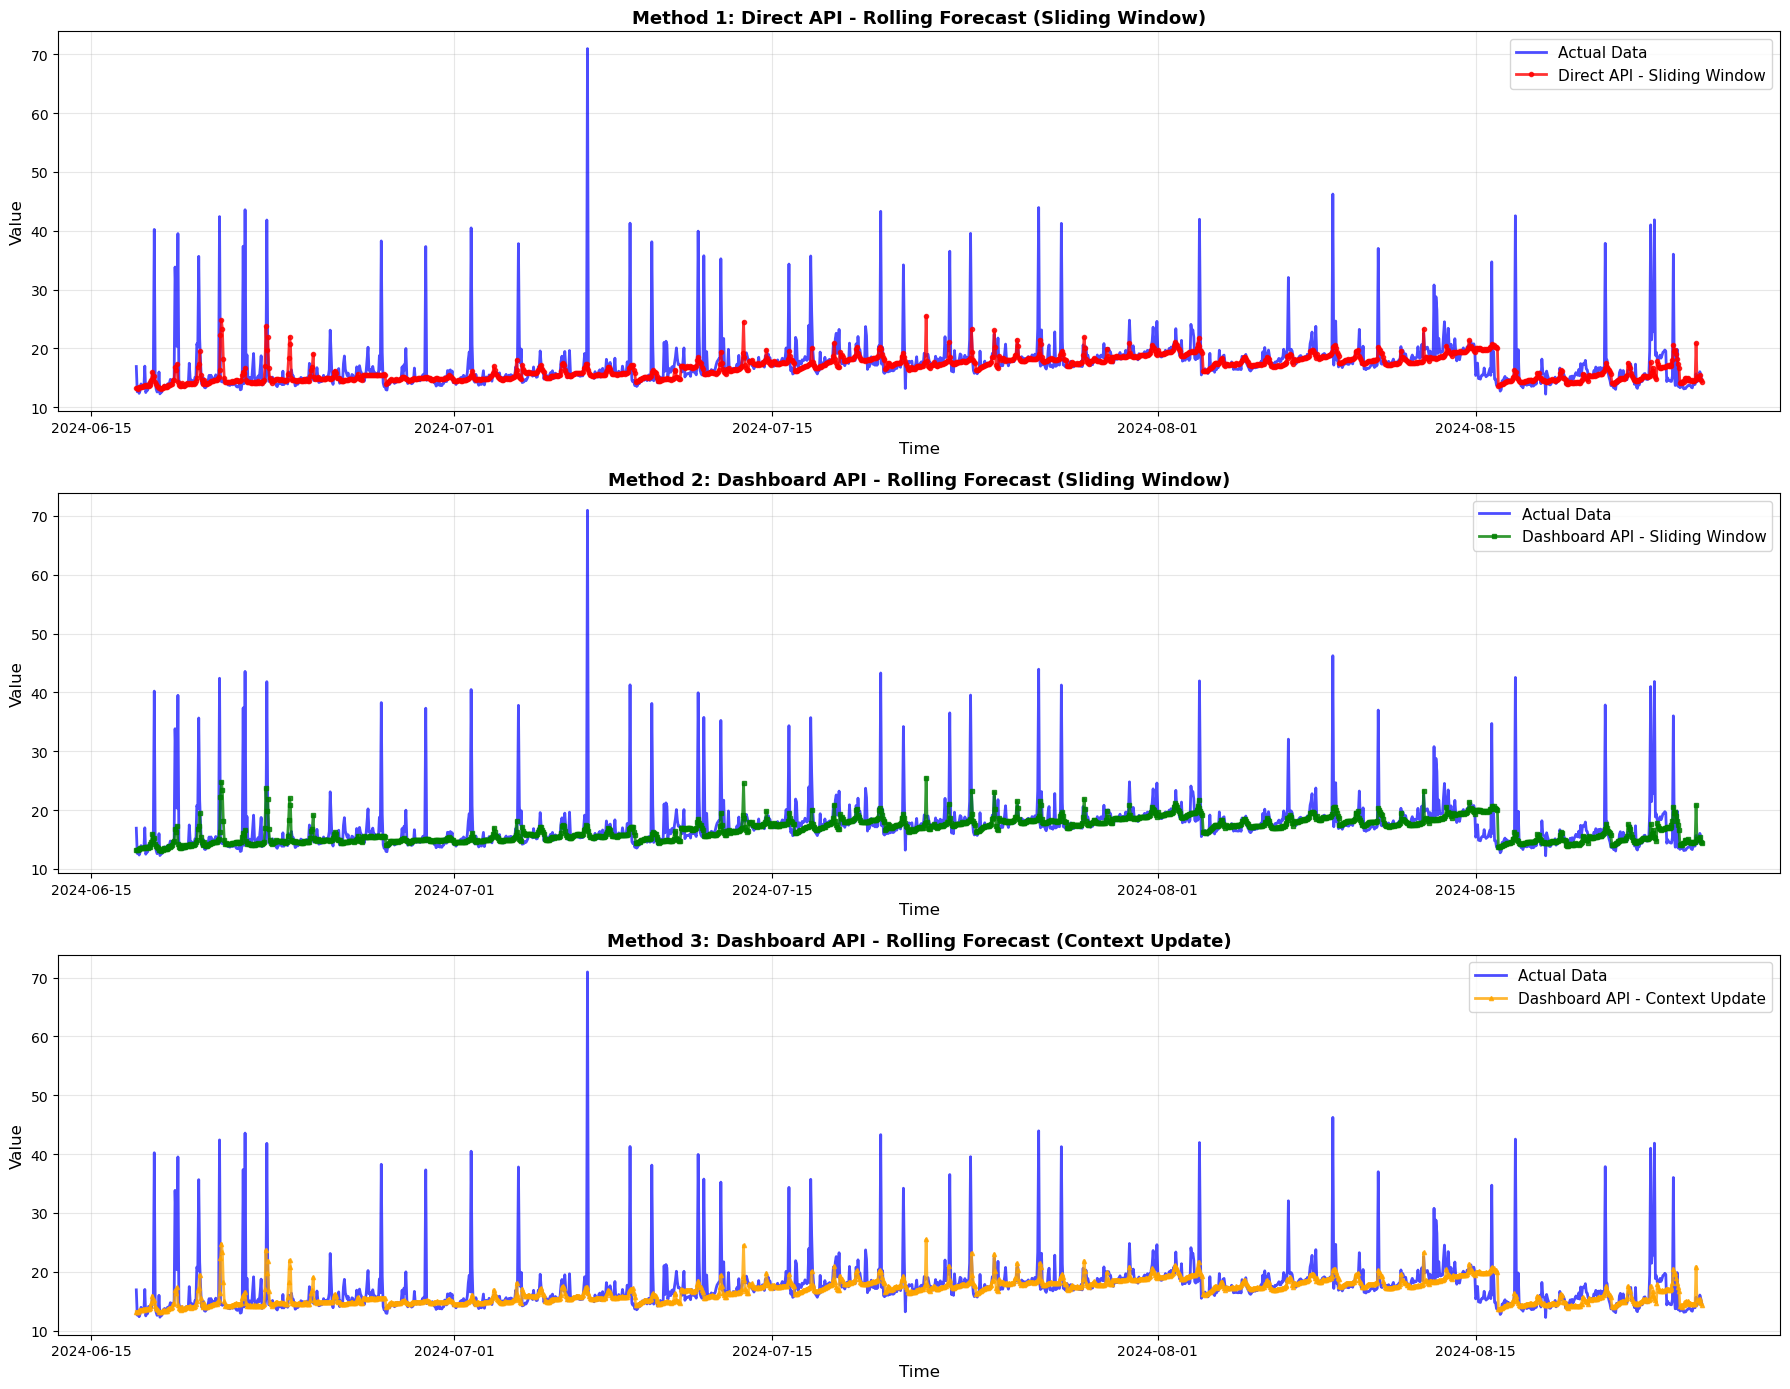


COMPARISON: All Three Approaches


In [ ]:
# Create comprehensive comparison visualization
fig, axes = plt.subplots(3, 1, figsize=(18, 14))

forecast_region_df = df.iloc[TRAIN_LENGTH:]

# Plot 1: Direct API - Sliding Window
ax1 = axes[0]
ax1.plot(forecast_region_df.index, forecast_region_df['target'], 
         label='Actual Data', color='blue', linewidth=2, alpha=0.7)
ax1.plot(rolling_forecast_df.index, rolling_forecast_df.values, 
         label='Direct API - Sliding Window', color='red', linewidth=2, 
         marker='o', markersize=3, alpha=0.8)
ax1.set_xlabel('Time', fontsize=12)
ax1.set_ylabel('Value', fontsize=12)
ax1.set_title('Method 1: Direct API - Rolling Forecast (Sliding Window)', 
              fontsize=13, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Plot 2: Dashboard API - Sliding Window
ax2 = axes[1]
dashboard_sliding_df = dashboard_sliding_pred.to_pd()
ax2.plot(forecast_region_df.index, forecast_region_df['target'], 
         label='Actual Data', color='blue', linewidth=2, alpha=0.7)
ax2.plot(dashboard_sliding_df.index, dashboard_sliding_df.values, 
         label='Dashboard API - Sliding Window', color='green', linewidth=2, 
         marker='s', markersize=3, alpha=0.8)
ax2.set_xlabel('Time', fontsize=12)
ax2.set_ylabel('Value', fontsize=12)
ax2.set_title('Method 2: Dashboard API - Rolling Forecast (Sliding Window)', 
              fontsize=13, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

# Plot 3: Dashboard API - Context Update
ax3 = axes[2]
dashboard_update_df = dashboard_update_pred.to_pd()
ax3.plot(forecast_region_df.index, forecast_region_df['target'], 
         label='Actual Data', color='blue', linewidth=2, alpha=0.7)
ax3.plot(dashboard_update_df.index, dashboard_update_df.values, 
         label='Dashboard API - Context Update', color='orange', linewidth=2, 
         marker='^', markersize=3, alpha=0.8)
ax3.set_xlabel('Time', fontsize=12)
ax3.set_ylabel('Value', fontsize=12)
ax3.set_title('Method 3: Dashboard API - Rolling Forecast (Context Update)', 
              fontsize=13, fontweight='bold')
ax3.legend(fontsize=11)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("COMPARISON: All Three Approaches")
print("=" * 80)

In [ ]:
# Calculate metrics for all three approaches
approaches = [
    ("Direct API - Sliding", rolling_forecast_df),
    ("Dashboard API - Sliding", dashboard_sliding_df),
    ("Dashboard API - Update", dashboard_update_df)
]

print(f"\n{'Approach':<30} {'MAE':<12} {'RMSE':<12} {'MAPE':<10}")
print("-" * 64)

for name, pred_df in approaches:
    # Get actual values for the prediction period
    actual = df.loc[pred_df.index, 'target'].values
    predicted = pred_df.values.flatten()
    
    # Calculate metrics
    mae_val = np.mean(np.abs(actual - predicted))
    rmse_val = np.sqrt(np.mean((actual - predicted) ** 2))
    mape_val = np.mean(np.abs((actual - predicted) / actual)) * 100
    
    print(f"{name:<30} {mae_val:<12.4f} {rmse_val:<12.4f} {mape_val:<10.2f}%")

print("=" * 80)
print("\n✓ Dashboard API rolling forecast testing complete!")


Approach                       MAE          RMSE         MAPE      
----------------------------------------------------------------
Direct API - Sliding           1.5023       3.7981       7.06      %
Dashboard API - Sliding        1.5023       3.7981       7.06      %
Dashboard API - Update         1.5023       3.7981       7.06      %

✓ Dashboard API rolling forecast testing complete!


### 8.4 Key Observations

**Dashboard API Integration:**
- ✅ Both rolling forecast modes (`rolling_sliding` and `rolling_update`) are now available
- ✅ Same parameters work across direct API and dashboard API
- ✅ Dashboard API provides additional features like progress tracking and visualization

**Performance Comparison:**
- **Direct API - Sliding**: Uses `model.rolling_forecast()` method directly
- **Dashboard API - Sliding**: Uses the same underlying method but through dashboard wrapper
- **Dashboard API - Update**: Uses context update approach - may differ slightly due to accumulated context

**When to use each:**
- **Direct API**: When you need fine-grained control or are scripting
- **Dashboard API - Sliding**: When using the web dashboard for efficient batch evaluation
- **Dashboard API - Update**: When simulating real-world incremental forecasting in the dashboard